In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from PycalcAct.dataset import Dataset
from PycalcAct.model import (
    MixedFCTemporalModel)
from PycalcAct.trainer import Trainer
from PycalcAct.calculateCustomAccuracy import calculateCustomAccuracy
from pathlib import Path
from PycalcAct.myCustomCriterion import myCustomCriterion
_ = torch.manual_seed(1234)


# dataFolder = "//Hmr_lymph/d/SebastienThis/CalciumPredictions/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"
dataFolder = "D:/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"

csv_path=[dataFolder + "legend.csv", dataFolder+"calciumRatio_normalized.csv"] 
csv_pos_path = dataFolder + "position.csv"

dataset = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path,  # Optional
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    customFilter = False,
    is_regression = False, #True
)
dataset.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

# Setup model
model = MixedFCTemporalModel(
    n_classes=4, #1,
    n_rnn_layers=3,
    rnn_hidden_size=32,
    n_fc_layers=1,
    fc_hidden_size=32,
    temporal_length=dataset.length_serie,
    input_size=dataset.features,
    bidirectional=True,
    pooling=None,
    dropout=0.2
)   

# Setup training
n_epochs = 500
        
trainer = Trainer(
    dataset,
    model,
    device="cuda",
    batch_size=5000,
    criterion=None,
    is_regression=False, #True,
    regression_bounds = None,#torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.


In [2]:
trainer.summary()   
trainer.train(n_epochs)
print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.35 │                     26.81 │
│             1             │                      1.30 │                     43.36 │
│             3             │                      1.21 │                     49.04 │
│             4             │                      1.21 │                     50.03 │
│             5             │                      1.19 │                     50.08 │
│             6             │                      1.18 │                     50.15 │
│             12            │                      1.17 │                     50.99 │
│             20    

D:\sebastien\PycalcActivation\src\PycalcAct\trainer.py:265: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.5961, device='cuda:0'),
 'CohenKappa': tensor(0.4195, device='cuda:0')}

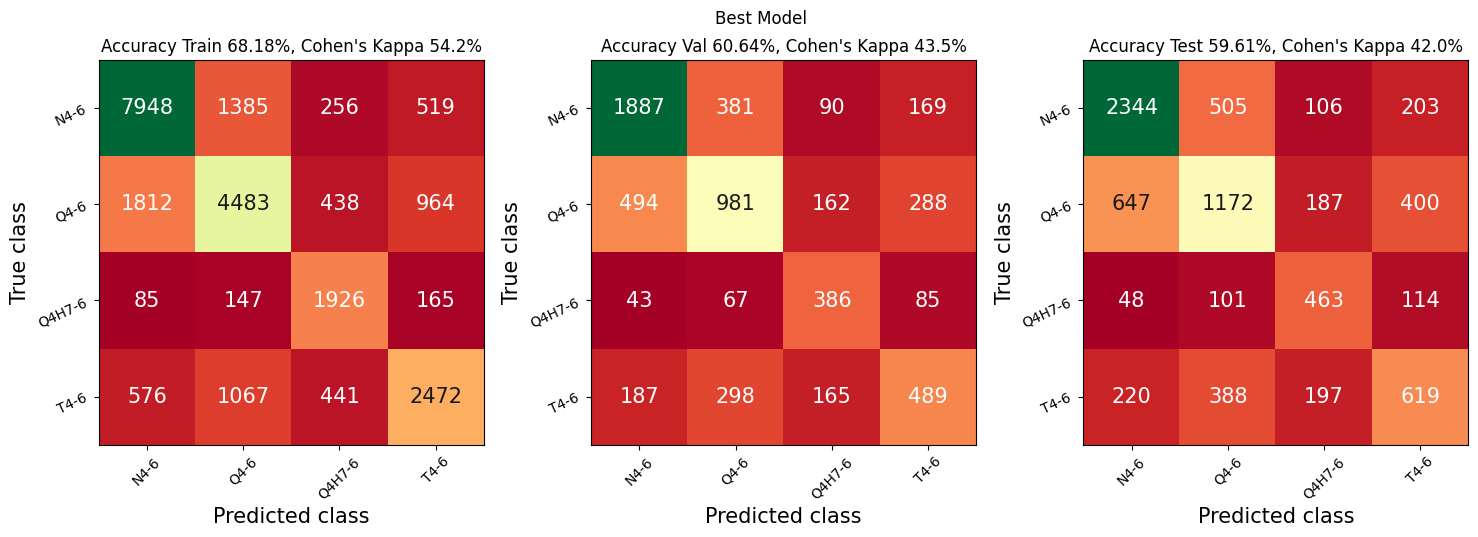

In [3]:
trainer.test("best")

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from PycalcAct.dataset import Dataset
from PycalcAct.model import (
    MixedFCTemporalModel)
from PycalcAct.trainer import Trainer
from pathlib import Path
from PycalcAct.myCustomCriterion import myCustomCriterion
_ = torch.manual_seed(1234)

# dataFolder = "//Hmr_lymph/d/SebastienThis/CalciumPredictions/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"
dataFolder = "D:/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"

csv_path=[dataFolder + "legend.csv", dataFolder+"calciumRatio_normalized.csv"] 
csv_pos_path = dataFolder + "position.csv"

dataset2 = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path,  # Optional
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    customFilter = False,
    is_regression = True
)
dataset2.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

# Setup model
model2 = MixedFCTemporalModel(
    n_classes= 1,
    n_rnn_layers=3,
    rnn_hidden_size=32,
    n_fc_layers=1,
    fc_hidden_size=32,
    temporal_length=dataset2.length_serie,
    input_size=dataset2.features,
    bidirectional=True,
    pooling=None,
    dropout=0.2
)   

# Setup training
n_epochs = 500
        
trainer2 = Trainer(
    dataset2,
    model2,
    device="cuda",
    batch_size=5000,
    criterion=None,
    is_regression=True,        
    use_class_weights=False,
    regression_bounds = torch.Tensor([0.5,1.5,2.5]).to("cuda") #torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.

trainer2.summary()   

Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
N4-6: 0.61 Q4-6: 0.80 Q4H7-6: 2.66 T4-6: 1.35 

,Total,N4-6,Q4-6,Q4H7-6,T4-6
Train,24684,10108,7697,2323,4556
Validation,6172,2527,1925,581,1139
Test,7714,3158,2406,726,1424
Total,38570,15793,12028,3630,7119


╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      2.00 │                     31.19 │
│             2             │                      1.54 │                     31.48 │
│             3             │                      1.52 │                     31.89 │
│             4             │                      1.47 │                     33.07 │
│             5             │                      1.45 │                     33.21 │
│             6             │                      1.43 │                     37.44 │
│             7             │                      1.43 │                     41.54 │
│             33            │                      1.28 │                     42.92 │
│             34            │                      1.2

D:\sebastien\PycalcActivation\src\PycalcAct\trainer.py:271: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.4246, device='cuda:0'),
 'CohenKappa': tensor(0.2107, device='cuda:0')}

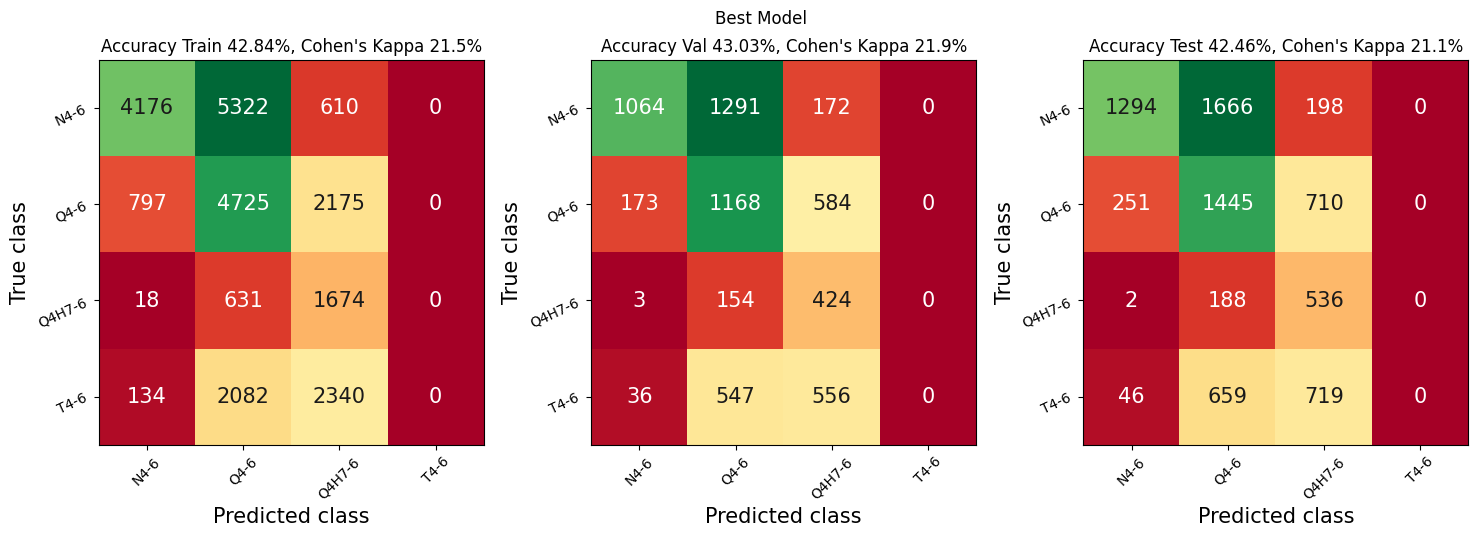

In [6]:
trainer2.train(n_epochs)
trainer2.test("best")

In [22]:
import torch.nn.functional as F
target = y_batch
print(target)
input = y_pred
weights = trainer2.dataset.weights
weight_list = target.tolist()
weight_dict = {
    0 : weights[0],
    1 : weights[1],
    2 : weights[2],
    3 : weights[3],
    }
weight_list = torch.Tensor([weight_dict[y] for y in weight_list])
print(weight_list)
print(input.device)
F.mse_loss(input.squeeze(), target, reduction='none', weight=weight_list.to("cuda"))

tensor([1., 1., 2.,  ..., 1., 3., 3.], device='cuda:0')
tensor([0.8017, 0.8017, 1.3545,  ..., 0.8017, 2.6565, 2.6565])
cuda:0


tensor([ 0.5155,  0.4773,  4.1042,  ...,  0.4083, 20.0682, 21.2418],
       device='cuda:0', grad_fn=<MulBackward0>)

In [9]:
from progress_table import ProgressTable
from copy import deepcopy
from torchmetrics.classification import Accuracy, CohenKappa, ConfusionMatrix
from torch import tensor

if trainer2.scheduler is None:
    trainer2.scheduler = trainer2.default_scheduler()(T_max=n_epochs)
    trainer2._initial_scheduler_state_dict = deepcopy(trainer2.scheduler.state_dict())
    trainer2._initial_scheduler_state_dict = deepcopy(trainer2.scheduler.state_dict())

x, y = trainer2.dataset.train_batch(True, to_cuda=True)
batch_size = len(x) if trainer2.batch_size is None else trainer2.batch_size

current_best = 0
xval, yval = trainer2.dataset.val_batch(True, to_cuda=True)
table = ProgressTable(
    num_decimal_places=2,
    print_header_every_n_rows=15,
    # print_header_every_n_rows=15,
    pbar_show_progress=True,
    pbar_style="square",
    default_column_width=25,
)

table.add_column("Epoch")
table.add_column("Loss", color="blue", alignment="right")
table.add_column(trainer2._store_best, color="green", alignment="right")
table.add_column("Loss", color="blue", alignment="right")
table.add_column(trainer2._store_best, color="green", alignment="right")

for e in table(
    range(n_epochs),
    total=n_epochs,
    description="Epoch",
    show_eta=True,
):
    idx = torch.randperm(x.shape[0], device=x.device)
    x = x[idx]
    y = y[idx]

    trainer2.model.train()
    for i in range(0, len(x), batch_size):
        trainer2.optim.zero_grad()
        x_batch = x[i : i + batch_size]
        if trainer2.is_regression:
            y_batch = y[i : i + batch_size].type(torch.FloatTensor).to(trainer2.device)
        else:
            y_batch = y[i : i + batch_size].type(torch.LongTensor).to(trainer2.device)
        # Take batch size:

        with torch.autocast("cuda"): #torch.cuda.amp.autocast()
            y_pred = trainer2.model(x_batch)
            loss = trainer2.criterion(y_pred, y_batch, weight=trainer2.dataset.weights)
            
        
        loss.backward()
        trainer2.optim.step()
    print(loss)
    thisParam = trainer2.model.final_layer.parameters()
    for p in thisParam:
        print(p.grad)

    if trainer2.scheduler:
        trainer2.scheduler.step()
    # table.update("Loss", loss.item(), aggregate="mean", color="blue")
    # table.update("Epoch", e)
    # table.update("Loss", loss.item(), aggregate="mean", color="blue")
    # table.update("Epoch", e)
    # if e % 10 == 0:
    #     if trainer2.is_regression:
    #         loss, scores = trainer2.eval(xval, yval.type(torch.FloatTensor).to(trainer2.device))
    #     else:
    #         loss, scores = trainer2.eval(xval, yval.type(torch.LongTensor).to(trainer2.device))
    #     if scores[trainer2._store_best] > current_best:
    #         current_best = scores[trainer2._store_best]
    #         trainer2._best_state_dict = deepcopy(trainer2.model.state_dict())
    #         if True:
    #             table.update(trainer2._store_best, scores[trainer2._store_best].item() * 100, color="green")
    #             table.update(trainer2._store_best, scores[trainer2._store_best].item() * 100, color="green")

    #         table.next_row()

TypeError: myMSELoss.__call__() got an unexpected keyword argument 'weight'

In [19]:
thisParam = trainer2.model.final_layer.parameters()
for p in thisParam:
    print(p.data)


tensor([[-8.9183e-02,  7.0683e-02,  1.1796e-01,  1.4007e-01,  1.0864e-01,
         -1.3578e-01, -1.1285e-03,  8.1036e-02,  1.6682e-02,  1.3180e-02,
          4.1223e-02, -2.5919e-03,  1.2365e-01, -9.9948e-02,  5.7034e-02,
         -1.1707e-02,  1.3201e-01, -3.4253e-02,  8.9308e-02, -9.9209e-32,
          1.3257e-01,  1.1423e-01,  2.9868e-02, -7.0060e-02,  7.8846e-02,
          1.3038e-01,  1.6720e-04,  8.8676e-02,  8.7860e-03, -6.3405e-02,
          1.4140e-01,  1.5821e-01]], device='cuda:0')
tensor([0.7671], device='cuda:0')


In [ ]:
#         # save metrics
# trainer.register_last_state()
# fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# trainer.model.load_state_dict(trainer._best_state_dict)
# fig.suptitle("Best Model")
# fig.suptitle("Best Model")


# callbacks = (
#         trainer.dataset.train_batch,
#         trainer.dataset.val_batch,
#         trainer.dataset.test_batch,
# )

# for i, (name, callable) in enumerate(zip(["Train", "Val", "Test"], callbacks)):
#     x, y = callable(True, to_cuda=True)
#     trainer.model.eval()
#     trainer.metrics.reset()
#     trainer.confmat.reset()

#     batch_size = len(x) if trainer.batch_size is None else trainer.batch_size

#     with torch.no_grad():
#         for i in range(0, len(x), batch_size):
#             xbatch = x[i : i + batch_size]
#             if trainer.is_regression:
#                 ybatch = y[i : i + batch_size].type(torch.FloatTensor).to(trainer.device)
#             else:
#                 ybatch = y[i : i + batch_size].type(torch.LongTensor).to(trainer.device)

#             y_pred = trainer.model(xbatch)
#             loss = trainer.criterion(y_pred.squeeze(), ybatch)

#             if trainer.is_regression:
#                 # From continuous to categorical
#                 # use regression_bounds to define the thresholds
#                 y_pred = torch.bucketize(y_pred.squeeze(), trainer.regression_bounds).to(trainer.device)
#                 ybatch = torch.bucketize(ybatch.squeeze(), trainer.regression_bounds).to(trainer.device)
#             else:
#                 y_pred = torch.softmax(y_pred, dim=1)
#             trainer.metrics.update(y_pred, ybatch)
#             trainer.confmat.update(y_pred, ybatch)
#             scores = trainer.metrics.compute()
#     axs[i].set_title(
#     f"Accuracy {(name)} {scores['Accuracy'].item():.2%}, Cohen's Kappa {scores['CohenKappa'].item():.1%}"
#     )
#     trainer.confmat.plot(
#     ax=axs[i],
#     cmap="RdYlGn",
#     labels=trainer.dataset.labels,
#     )
# fig.show()
   
# # narr = np.array([metrics['Accuracy'].tolist(), metrics['CohenKappa'].tolist()])
# fig.show()
